# Cosc 301 - March Madness Project Pipeline Python Section
#### Nicholas Lookkin 40126518

### Imports

In [56]:
import os
import pandas as pd
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Set working directory to project root
path = os.getcwd()
proj = "March-Machine-Learning-Mania-2026-March-Madness-Analytics"

if not path.endswith(proj):
    project_root = os.path.join(path, proj)
else:
    project_root = path

if os.path.exists(project_root):
    os.chdir(project_root)
    print(f"Working directory set: {os.getcwd()}")
else:
    print(f"Path not found: {project_root}")

Working directory set: C:\Users\nicho\OneDrive\Desktop\Cosc301_Proj\March-Machine-Learning-Mania-2026-March-Madness-Analytics


## Import datasets
Has implementation for both locally and Bigquery, local is used for simplicity with bigQuery Commented out

In [57]:
#sqlite implementation
con = sqlite3.connect("data/march_madness.db")
season_stats = pd.read_sql("SELECT * FROM season_stats", con)
seeds = pd.read_sql("SELECT * FROM seeds_clean", con)
con.close()

# commented for easier implementation and reproducibility
# BigQuery (Proof of working cloud storage)
# import pandas_gbq
# project_id = "project-d89b8a4e-b5a7-4457-970"
# season_stats = pandas_gbq.read_gbq("SELECT * FROM `ncaa.season_stats`", project_id=project_id)
# seeds = pandas_gbq.read_gbq("SELECT * FROM `ncaa.seeds_clean`", project_id=project_id)

print(season_stats.shape)
season_stats.head()

(8346, 19)


,Season,TeamID,Games,Wins,Losses,WinPct,AvgScore,AvgOppScore,AvgPointDiff,AvgFGA3,AvgFGPct,AvgFG3Pct,AvgFTPct,AvgReb,AvgAst,AvgTO,AvgStl,AvgBlk,TeamName
0,2003.0,1102.0,28.0,12.0,16.0,0.428571,57.250000,57.000000,0.250000,20.821429,0.486149,0.367637,0.642402,21.000000,13.000000,11.428571,5.964286,1.785714,Air Force
1,2003.0,1103.0,27.0,13.0,14.0,0.481481,78.777778,78.148148,0.629630,16.074074,0.487294,0.331990,0.735271,29.703704,15.222222,12.629630,7.259259,2.333333,Akron
2,2003.0,1104.0,28.0,17.0,11.0,0.607143,69.285714,65.000000,4.285714,19.857143,0.419676,0.325442,0.705168,37.500000,12.107143,13.285714,6.607143,3.785714,Alabama
3,2003.0,1105.0,26.0,7.0,19.0,0.269231,71.769231,76.653846,-4.884615,20.769231,0.396204,0.359630,0.709598,36.615385,14.538462,18.653846,9.307692,2.076923,Alabama A&M
4,2003.0,1106.0,28.0,13.0,15.0,0.464286,63.607143,63.750000,-0.142857,17.642857,0.425530,0.350196,0.623158,36.142857,11.678571,17.035714,8.357143,3.142857,Alabama St


## Load data / Define Features

In [58]:
tourney = pd.read_csv("data/raw/MNCAATourneyCompactResults.csv")
print(tourney.shape)
tourney.head()

(2585, 8)


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0


In [59]:
# Merge winner season stats
df = tourney.merge(season_stats, left_on=["Season", "WTeamID"], right_on=["Season", "TeamID"])
df = df.drop(columns=["TeamID"])
df = df.rename(columns={col: "W_" + col for col in season_stats.columns if col not in ["Season", "TeamID", "TeamName"]})

# Merge loser season stats
df = df.merge(season_stats, left_on=["Season", "LTeamID"], right_on=["Season", "TeamID"])
df = df.drop(columns=["TeamID"])
df = df.rename(columns={col: "L_" + col for col in season_stats.columns if col not in ["Season", "TeamID", "TeamName"]})

# Merge seeds
df = df.merge(seeds[["Season", "TeamID", "SeedNum"]], left_on=["Season", "WTeamID"], right_on=["Season", "TeamID"])
df = df.drop(columns=["TeamID"])
df = df.rename(columns={"SeedNum": "WSeed"})

df = df.merge(seeds[["Season", "TeamID", "SeedNum"]], left_on=["Season", "LTeamID"], right_on=["Season", "TeamID"])
df = df.drop(columns=["TeamID"])
df = df.rename(columns={"SeedNum": "LSeed"})

print(df.shape)
df.head()

(1449, 44)


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,W_Games,W_Wins,...,L_AvgFG3Pct,L_AvgFTPct,L_AvgReb,L_AvgAst,L_AvgTO,L_AvgStl,L_AvgBlk,TeamName_y,WSeed,LSeed
0,2003,134,1421,92,1411,84,N,1,29.0,13.0,...,0.321414,0.613745,37.966667,14.200000,15.233333,6.433333,2.233333,TX Southern,16.0,16.0
1,2003,136,1112,80,1436,51,N,0,28.0,25.0,...,0.357920,0.649708,38.689655,14.206897,14.068966,6.862069,2.965517,Vermont,1.0,16.0
2,2003,136,1113,84,1272,71,N,0,29.0,18.0,...,0.343441,0.628299,40.034483,16.620690,13.793103,7.379310,5.068966,Memphis,10.0,7.0
3,2003,136,1141,79,1166,73,N,0,29.0,23.0,...,0.384914,0.689707,34.060606,16.818182,13.363636,8.393939,4.454545,Creighton,11.0,6.0
4,2003,136,1143,76,1301,74,N,1,29.0,21.0,...,0.350564,0.778148,31.766667,14.666667,14.200000,7.766667,3.066667,NC State,8.0,9.0


## Momentum Statistic

In [60]:
# Load momentum data
streak = pd.read_csv("data/cleaned/streak_data.csv")

# Merge winner momentum
df = df.merge(streak[["Season", "TeamID", "Last10WinPct", "MomentumDelta"]], 
              left_on=["Season", "WTeamID"], right_on=["Season", "TeamID"])
df = df.rename(columns={"Last10WinPct": "W_Last10WinPct", "MomentumDelta": "W_MomentumDelta"})
df = df.drop(columns=["TeamID"])

# Merge loser momentum
df = df.merge(streak[["Season", "TeamID", "Last10WinPct", "MomentumDelta"]], 
              left_on=["Season", "LTeamID"], right_on=["Season", "TeamID"])
df = df.rename(columns={"Last10WinPct": "L_Last10WinPct", "MomentumDelta": "L_MomentumDelta"})
df = df.drop(columns=["TeamID"])

## Build Dataset for the model

In [61]:
# Define feature columns (differences between teams)
# Without momentum
feature_cols_base = ["W_WinPct", "W_AvgPointDiff", "W_AvgFGPct", "W_AvgFG3Pct", 
                "W_AvgReb", "W_AvgAst", "W_AvgTO", "WSeed",
                "L_WinPct", "L_AvgPointDiff", "L_AvgFGPct", "L_AvgFG3Pct",
                "L_AvgReb", "L_AvgAst", "L_AvgTO", "LSeed"]

# With momentum
feature_cols_momentum = feature_cols_base + ["W_Last10WinPct", "W_MomentumDelta", 
                                              "L_Last10WinPct", "L_MomentumDelta"]

# Winner always has label 1 — create flipped version for balance
df["label"] = 1

df_flipped = df.copy()
df_flipped = df_flipped.rename(columns={
    "WTeamID": "LTeamID", "LTeamID": "WTeamID",
    "WSeed": "LSeed", "LSeed": "WSeed",
    **{col: col.replace("W_", "L_") if col.startswith("W_") else col.replace("L_", "W_") if col.startswith("L_") else col for col in feature_cols_momentum}
})
df_flipped["label"] = 0



## Training test Split

In [62]:
# Split by season to avoid data leakage (train on older seasons, test on recent)
balanced = pd.concat([df, df_flipped]).reset_index(drop=True)

train = balanced[balanced["Season"] < 2022]
test = balanced[balanced["Season"] >= 2022]

X_train_base = train[feature_cols_base]
X_test_base = test[feature_cols_base]
X_train_mom = train[feature_cols_momentum]
X_test_mom = test[feature_cols_momentum]
y_train = train["label"]
y_test = test["label"]

#weight recent more highly for changes in gameplay
min_season = train["Season"].min()
max_season = train["Season"].max()
sample_weights = ((train["Season"] - min_season) / (max_season - min_season)).values

print("Train size:", X_train_base.shape)
print("Test size:", X_test_base.shape)

Train size: (2362, 16)
Test size: (536, 16)


## Logistic Regression

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Logistic Regression
lr_base = LogisticRegression(max_iter=1000)
lr_base.fit(X_train_base, y_train, sample_weight=sample_weights)

lr_mom = LogisticRegression(max_iter=1000)
lr_mom.fit(X_train_mom, y_train, sample_weight=sample_weights)

print("LR Base     | Accuracy:", accuracy_score(y_test, lr_base.predict(X_test_base)), "| Log Loss:", log_loss(y_test, lr_base.predict_proba(X_test_base)))
print("LR Momentum | Accuracy:", accuracy_score(y_test, lr_mom.predict(X_test_mom)), "| Log Loss:", log_loss(y_test, lr_mom.predict_proba(X_test_mom)))

LR Base     | Accuracy: 0.6231343283582089 | Log Loss: 0.6389673845973504
LR Momentum | Accuracy: 0.6194029850746269 | Log Loss: 0.636462701368052


## Random Forest

In [64]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train_base, y_train, sample_weight=sample_weights)

rf_mom = RandomForestClassifier(n_estimators=100, random_state=42)
rf_mom.fit(X_train_mom, y_train, sample_weight=sample_weights)

print("RF Base     | Accuracy:", accuracy_score(y_test, rf_base.predict(X_test_base)), "| Log Loss:", log_loss(y_test, rf_base.predict_proba(X_test_base)))
print("RF Momentum | Accuracy:", accuracy_score(y_test, rf_mom.predict(X_test_mom)), "| Log Loss:", log_loss(y_test, rf_mom.predict_proba(X_test_mom)))

RF Base     | Accuracy: 0.707089552238806 | Log Loss: 0.4979125641282782
RF Momentum | Accuracy: 0.7518656716417911 | Log Loss: 0.48385671533561025


## Xgboost


In [65]:
import xgboost as xgb

# XGBoost
xgb_base = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_base.fit(X_train_base, y_train, sample_weight=sample_weights)

xgb_mom = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_mom.fit(X_train_mom, y_train, sample_weight=sample_weights)

print("XGB Base     | Accuracy:", accuracy_score(y_test, xgb_base.predict(X_test_base)), "| Log Loss:", log_loss(y_test, xgb_base.predict_proba(X_test_base)))
print("XGB Momentum | Accuracy:", accuracy_score(y_test, xgb_mom.predict(X_test_mom)), "| Log Loss:", log_loss(y_test, xgb_mom.predict_proba(X_test_mom)))

XGB Base     | Accuracy: 0.7313432835820896 | Log Loss: 0.5606636997774699
XGB Momentum | Accuracy: 0.7854477611940298 | Log Loss: 0.46645518283988685


## Model Comparasions

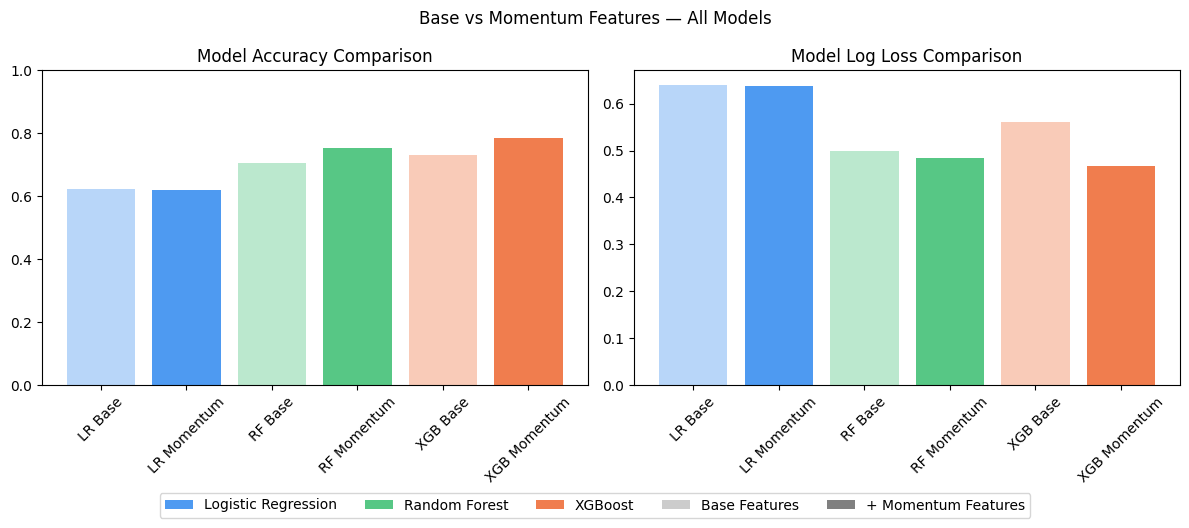

In [66]:
model_colors = {
    "LR": "#4e9af1",
    "RF": "#57c785",
    "XGB": "#f07d4e"
}

colors = [model_colors["LR"], model_colors["LR"],
          model_colors["RF"], model_colors["RF"],
          model_colors["XGB"], model_colors["XGB"]]

alphas = [0.4, 1.0, 0.4, 1.0, 0.4, 1.0]  # light = base, dark = momentum

results = pd.DataFrame({
    "Model": ["LR Base", "LR Momentum",
              "RF Base", "RF Momentum",
              "XGB Base", "XGB Momentum"],
    "Accuracy": [
        accuracy_score(y_test, lr_base.predict(X_test_base)),
        accuracy_score(y_test, lr_mom.predict(X_test_mom)),
        accuracy_score(y_test, rf_base.predict(X_test_base)),
        accuracy_score(y_test, rf_mom.predict(X_test_mom)),
        accuracy_score(y_test, xgb_base.predict(X_test_base)),
        accuracy_score(y_test, xgb_mom.predict(X_test_mom)),
    ],
    "LogLoss": [
        log_loss(y_test, lr_base.predict_proba(X_test_base)),
        log_loss(y_test, lr_mom.predict_proba(X_test_mom)),
        log_loss(y_test, rf_base.predict_proba(X_test_base)),
        log_loss(y_test, rf_mom.predict_proba(X_test_mom)),
        log_loss(y_test, xgb_base.predict_proba(X_test_base)),
        log_loss(y_test, xgb_mom.predict_proba(X_test_mom)),
    ]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars0 = axes[0].bar(results["Model"], results["Accuracy"], color=colors)
for bar, alpha in zip(bars0, alphas):
    bar.set_alpha(alpha)
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=45)

bars1 = axes[1].bar(results["Model"], results["LogLoss"], color=colors)
for bar, alpha in zip(bars1, alphas):
    bar.set_alpha(alpha)
axes[1].set_title("Model Log Loss Comparison")
axes[1].tick_params(axis="x", rotation=45)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4e9af1", label="Logistic Regression"),
    Patch(facecolor="#57c785", label="Random Forest"),
    Patch(facecolor="#f07d4e", label="XGBoost"),
    Patch(facecolor="gray", alpha=0.4, label="Base Features"),
    Patch(facecolor="gray", alpha=1.0, label="+ Momentum Features"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Base vs Momentum Features — All Models")
plt.tight_layout()
plt.savefig("reports/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Feature Importance Analysis

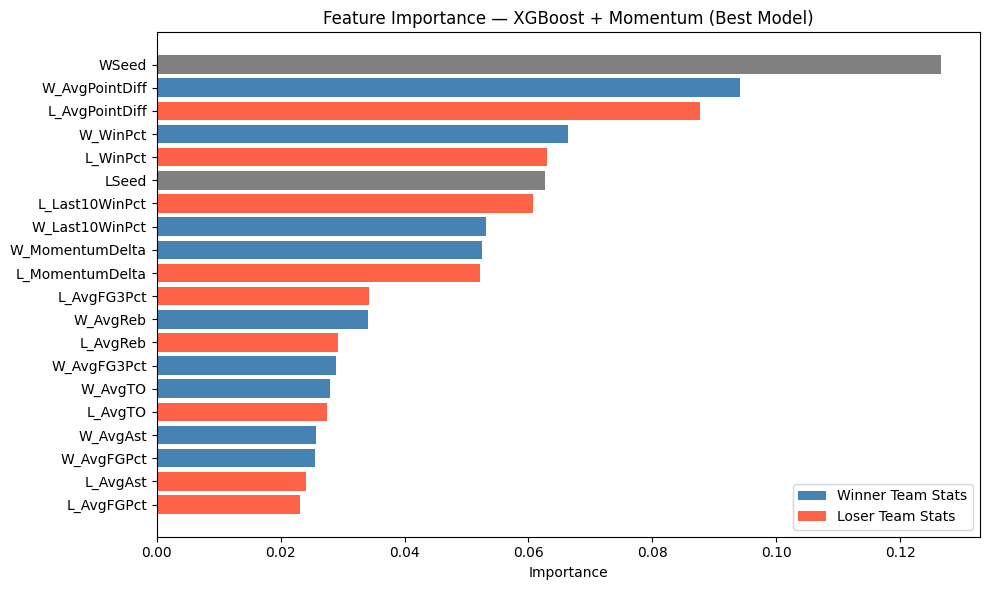

            Feature  Importance
7             WSeed    0.126568
1    W_AvgPointDiff    0.094156
9    L_AvgPointDiff    0.087669
0          W_WinPct    0.066453
8          L_WinPct    0.063022
15            LSeed    0.062644
18   L_Last10WinPct    0.060754
16   W_Last10WinPct    0.053208
17  W_MomentumDelta    0.052522
19  L_MomentumDelta    0.052223
11      L_AvgFG3Pct    0.034312
4          W_AvgReb    0.034090
12         L_AvgReb    0.029309
3       W_AvgFG3Pct    0.028981
6           W_AvgTO    0.027899
14          L_AvgTO    0.027561
5          W_AvgAst    0.025786
2        W_AvgFGPct    0.025528
13         L_AvgAst    0.024147
10       L_AvgFGPct    0.023168


In [67]:
# Feature importance from best model (XGBoost + momentum)
importance_df = pd.DataFrame({
    "Feature": feature_cols_momentum,
    "Importance": xgb_mom.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
colors = ["steelblue" if "W_" in f else "tomato" if "L_" in f else "gray" for f in importance_df["Feature"]]
plt.barh(importance_df["Feature"], importance_df["Importance"], color=colors)
plt.xlabel("Importance")
plt.title("Feature Importance — XGBoost + Momentum (Best Model)")
plt.gca().invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="Winner Team Stats"),
    Patch(facecolor="tomato", label="Loser Team Stats"),
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig("reports/featureImportance.png", dpi=150, bbox_inches="tight")
plt.show()

print(importance_df)

## Model Performance as tournament advances

C:\Users\nicho\AppData\Local\Temp\ipykernel_35764\2715228931.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Round"] = test["DayNum"].map(get_round)


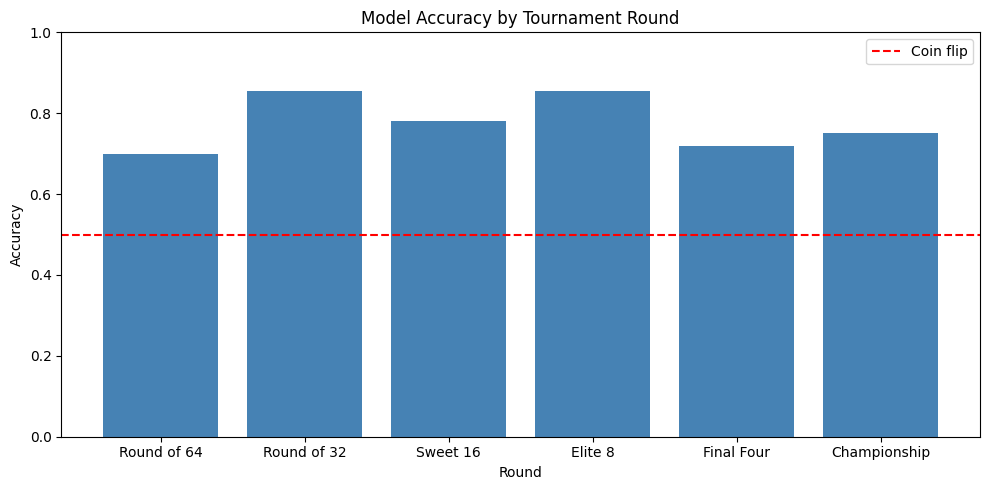

In [68]:
# Map DayNum to tournament round
def get_round(daynum):
    if daynum <= 136: return "Round of 64"
    elif daynum <= 138: return "Round of 32"
    elif daynum <= 143: return "Sweet 16"
    elif daynum <= 145: return "Elite 8"
    elif daynum <= 152: return "Final Four"
    else: return "Championship"

test["Round"] = test["DayNum"].map(get_round)

# Get predictions from best model
test = test.copy()
test["pred"] = xgb_mom.predict(X_test_mom)
test["correct"] = (test["pred"] == test["label"]).astype(int)

# Accuracy by round
round_acc = test.groupby("Round")["correct"].mean().reset_index()
round_acc.columns = ["Round", "Accuracy"]

# Order rounds properly
round_order = ["Round of 64", "Round of 32", "Sweet 16", "Elite 8", "Final Four", "Championship"]
round_acc["Round"] = pd.Categorical(round_acc["Round"], categories=round_order, ordered=True)
round_acc = round_acc.sort_values("Round")

plt.figure(figsize=(10, 5))
plt.bar(round_acc["Round"], round_acc["Accuracy"], color="steelblue")
plt.axhline(y=0.5, linestyle="dashed", color="red", label="Coin flip")
plt.ylim(0, 1)
plt.title("Model Accuracy by Tournament Round")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("reports/AccuracyByRound.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Models

In [69]:
import joblib

joblib.dump(xgb_mom, "models/xgb_momentum.pkl")
joblib.dump(rf_mom, "models/rf_momentum.pkl")
joblib.dump(lr_base, "models/lr_base.pkl")

['models/lr_base.pkl']